In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better styling
sns.set(style="whitegrid")

# Load data
df = pd.read_csv("Depression Professional Dataset (1).csv")

# Quick check
print(df.head())
print(df.info())


   Gender  Age  Work Pressure  Job Satisfaction Sleep Duration Dietary Habits  \
0  Female   37              2                 4      7-8 hours       Moderate   
1    Male   60              4                 3      5-6 hours      Unhealthy   
2  Female   42              2                 3      5-6 hours       Moderate   
3  Female   44              3                 5      7-8 hours        Healthy   
4    Male   48              4                 3      7-8 hours       Moderate   

  Have you ever had suicidal thoughts ?  Work Hours  Financial Stress  \
0                                    No           6                 2   
1                                   Yes           0                 4   
2                                    No           0                 2   
3                                   Yes           1                 2   
4                                   Yes           6                 5   

  Family History of Mental Illness Depression  
0                         

In [2]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("Numeric columns:", list(numeric_cols))
numeric_summary = df[numeric_cols].describe().T
print("\n=== Numeric Summary ===")
print(numeric_summary)


Numeric columns: ['Age', 'Work Pressure', 'Job Satisfaction', 'Work Hours', 'Financial Stress']

=== Numeric Summary ===
                   count       mean        std   min   25%   50%    75%   max
Age               2054.0  42.171860  11.461202  18.0  35.0  43.0  51.75  60.0
Work Pressure     2054.0   3.021908   1.417312   1.0   2.0   3.0   4.00   5.0
Job Satisfaction  2054.0   3.015093   1.418432   1.0   2.0   3.0   4.00   5.0
Work Hours        2054.0   5.930867   3.773945   0.0   3.0   6.0   9.00  12.0
Financial Stress  2054.0   2.978578   1.413362   1.0   2.0   3.0   4.00   5.0


In [3]:
# Select categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns:", list(cat_cols))

print("\n=== Categorical Summary (value counts & proportions) ===")
for col in cat_cols:
    print(f"\n---- {col} ----")
    print(df[col].value_counts())
    print("\nProportions:")
    print(df[col].value_counts(normalize=True).round(3))

Categorical columns: ['Gender', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness', 'Depression']

=== Categorical Summary (value counts & proportions) ===

---- Gender ----
Gender
Male      1066
Female     988
Name: count, dtype: int64

Proportions:
Gender
Male      0.519
Female    0.481
Name: proportion, dtype: float64

---- Sleep Duration ----
Sleep Duration
7-8 hours            530
Less than 5 hours    525
5-6 hours            505
More than 8 hours    494
Name: count, dtype: int64

Proportions:
Sleep Duration
7-8 hours            0.258
Less than 5 hours    0.256
5-6 hours            0.246
More than 8 hours    0.241
Name: proportion, dtype: float64

---- Dietary Habits ----
Dietary Habits
Unhealthy    713
Healthy      681
Moderate     660
Name: count, dtype: int64

Proportions:
Dietary Habits
Unhealthy    0.347
Healthy      0.332
Moderate     0.321
Name: proportion, dtype: float64

---- Have you ever had suicidal thoughts 

/tmp/ipython-input-2565847047.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


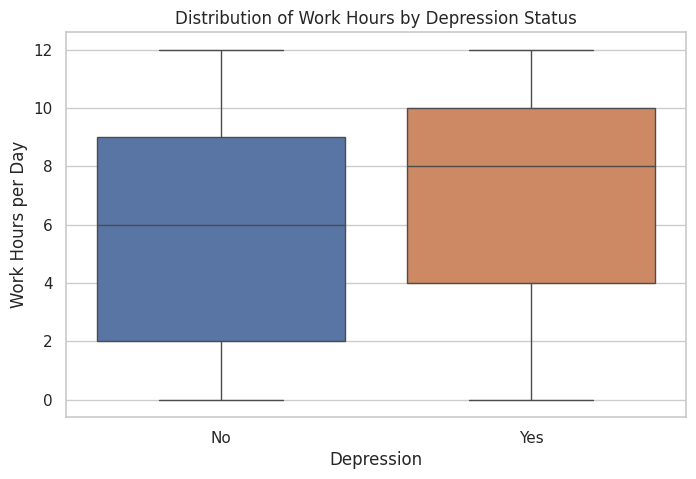

In [4]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Depression",
    y="Work Hours",
    palette=["#4C72B0", "#DD8452"]
)
plt.title("Distribution of Work Hours by Depression Status")
plt.xlabel("Depression")
plt.ylabel("Work Hours per Day")
plt.show()

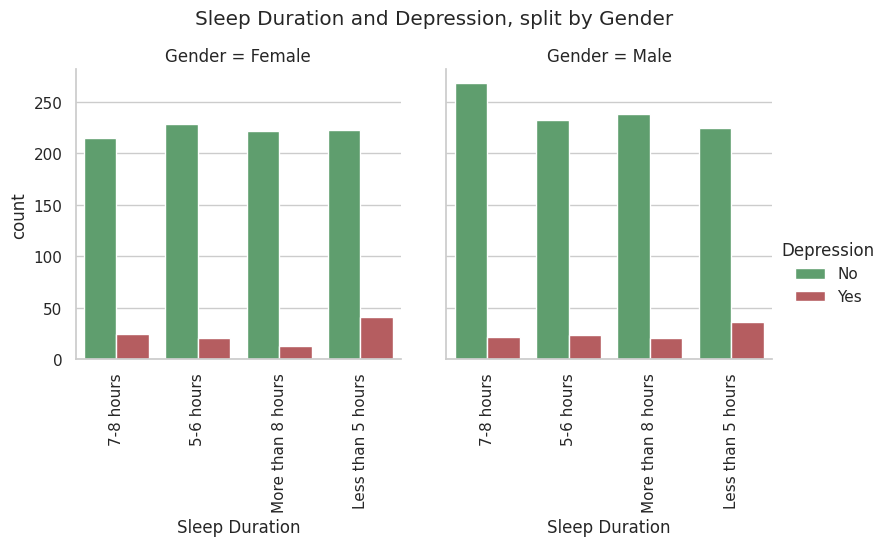

In [5]:
g = sns.catplot(
    data=df,
    x="Sleep Duration",
    hue="Depression",
    col="Gender",
    kind="count",
    palette=["#55A868", "#C44E52"],
    height=4,
    aspect=1
)
g.set_xticklabels(rotation=90)
g.fig.suptitle("Sleep Duration and Depression, split by Gender", y=1.05)
plt.show()


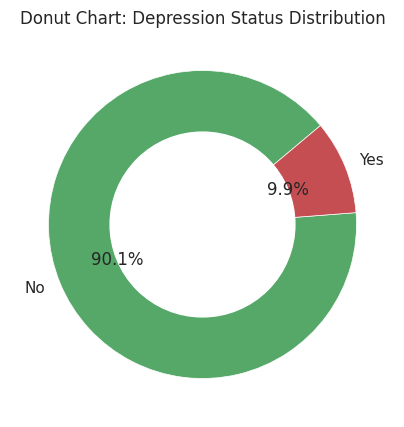

In [6]:
import matplotlib.pyplot as plt

# Count depression values
depression_counts = df["Depression"].value_counts()
colors = ["#55A868", "#C44E52"]
plt.figure(figsize=(5,5))
plt.pie(
    depression_counts,
    labels=depression_counts.index,
    autopct='%1.1f%%',
    startangle=40,
    colors=colors,
    wedgeprops={'linewidth':0.5, 'edgecolor': 'white'}
)
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Donut Chart: Depression Status Distribution")
plt.show()


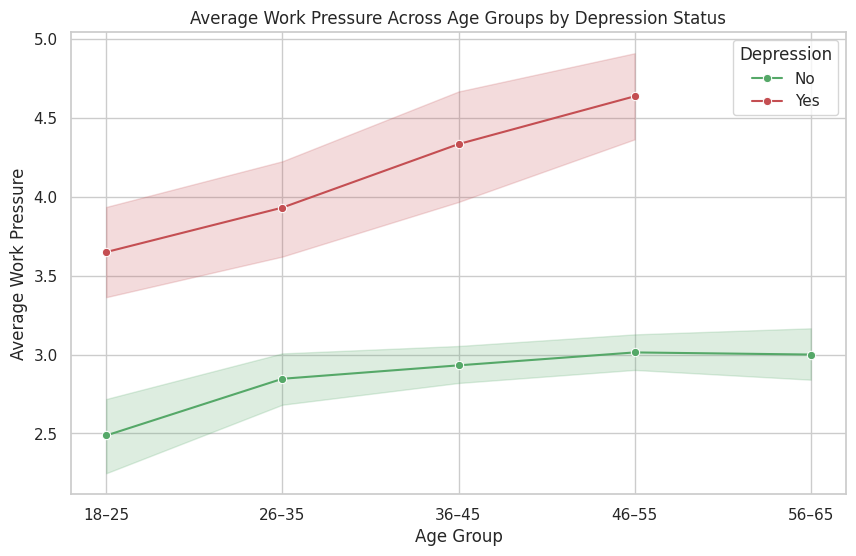

In [7]:

df["Age Group"] = pd.cut(
    df["Age"],
    bins=[18, 25, 35, 45, 55, 65],
    labels=["18–25", "26–35", "36–45", "46–55", "56–65"]
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="Age Group",
    y="Work Pressure",
    hue="Depression",
    marker="o",
    palette=["#55A868", "#C44E52"]
)
plt.title("Average Work Pressure Across Age Groups by Depression Status")
plt.xlabel("Age Group")
plt.ylabel("Average Work Pressure")
plt.show()

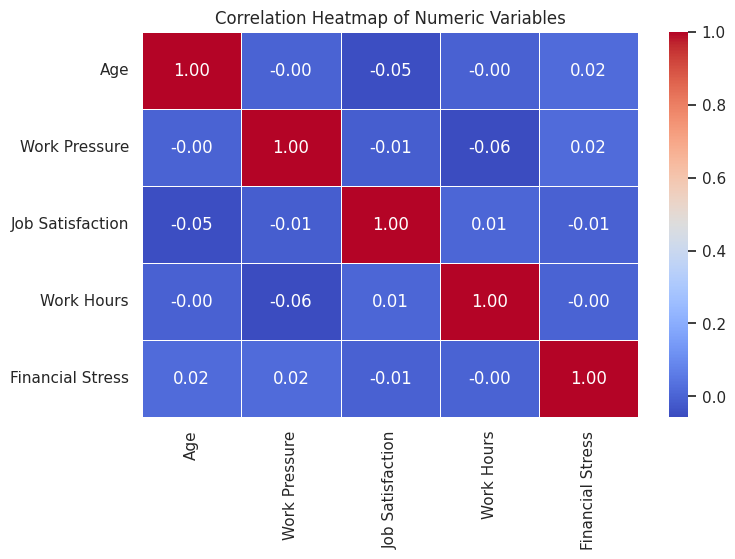

In [8]:
plt.figure(figsize=(8,5))
corr = df[["Age", "Work Pressure", "Job Satisfaction", "Work Hours", "Financial Stress"]].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",  # multi-colour
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [10]:
df = pd.read_csv("/content/Depression Professional Dataset (1).csv")
df["Depression"] = df["Depression"].map({"Yes":1, "No":0})


In [11]:
label = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = label.fit_transform(df[col])

In [12]:
X = df.drop("Depression", axis=1)
y = df["Depression"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
# Logistic Regression
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

Logistic Regression
Accuracy: 0.9805352798053528
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       368
           1       1.00      0.81      0.90        43

    accuracy                           0.98       411
   macro avg       0.99      0.91      0.94       411
weighted avg       0.98      0.98      0.98       411



In [16]:
#Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print(" Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

 Random Forest
Accuracy: 0.9562043795620438
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       368
           1       1.00      0.58      0.74        43

    accuracy                           0.96       411
   macro avg       0.98      0.79      0.86       411
weighted avg       0.96      0.96      0.95       411



In [17]:
# KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
print("KNN Classifier")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

KNN Classifier
Accuracy: 0.9440389294403893
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       368
           1       0.95      0.49      0.65        43

    accuracy                           0.94       411
   macro avg       0.95      0.74      0.81       411
weighted avg       0.94      0.94      0.94       411



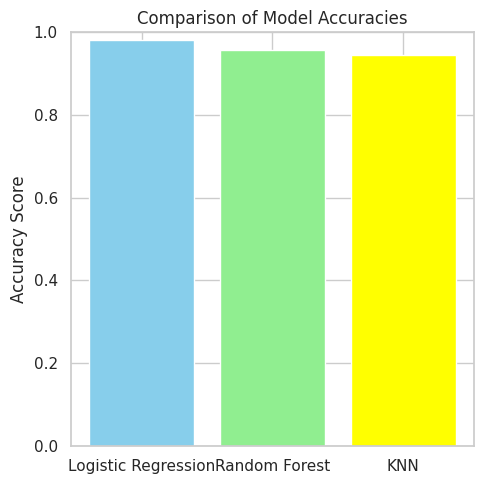

In [18]:
import matplotlib.pyplot as plt
log_acc = accuracy_score(y_test, log_pred)
rf_acc = accuracy_score(y_test, rf_pred)
knn_acc = accuracy_score(y_test, knn_pred)
models = ["Logistic Regression", "Random Forest", "KNN"]
accuracies = [log_acc, rf_acc, knn_acc]
colors = ['skyblue', 'lightgreen', 'yellow']
plt.figure(figsize=(5,5))
plt.bar(models, accuracies, color=colors)
plt.title("Comparison of Model Accuracies")
plt.ylabel("Accuracy Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()



In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import numpy as np

In [20]:
df = pd.read_csv("Depression Professional Dataset (1).csv")

In [21]:
label = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = label.fit_transform(df[col])
y = df["Age"]
X = df.drop("Age", axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
#Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
lin_pred = lin_model.predict(X_test)



In [ ]:
# Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)


In [23]:
#  Evaluation Metrics
def evaluate_model(true, pred):
    mae = mean_absolute_error(true, pred)
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, pred)
    return mae, mse, rmse, r2
lin_scores = evaluate_model(y_test, lin_pred)
rf_scores = evaluate_model(y_test, rf_pred)
print("\n===== Linear Regression =====")
print("MAE:", lin_scores[0])
print("MSE:", lin_scores[1])
print("RMSE:", lin_scores[2])
print("R²:", lin_scores[3])
print("\n===== Random Forest Regressor =====")
print("MAE:", rf_scores[0])
print("MSE:", rf_scores[1])
print("RMSE:", rf_scores[2])
print("R²:", rf_scores[3])


===== Linear Regression =====
MAE: 8.318267339367464
MSE: 101.17400413688969
RMSE: 10.05852892509087
R²: 0.25292105805814447

===== Random Forest Regressor =====
MAE: 41.627737226277375
MSE: 1870.4063260340633
RMSE: 43.2481944829384
R²: -12.811266945254646


In [27]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

df = pd.read_csv("Depression Professional Dataset (1).csv")

print("Data loaded. Shape:", df.shape)
print(df.head())


Data loaded. Shape: (2054, 11)
   Gender  Age  Work Pressure  Job Satisfaction Sleep Duration Dietary Habits  \
0  Female   37              2                 4      7-8 hours       Moderate   
1    Male   60              4                 3      5-6 hours      Unhealthy   
2  Female   42              2                 3      5-6 hours       Moderate   
3  Female   44              3                 5      7-8 hours        Healthy   
4    Male   48              4                 3      7-8 hours       Moderate   

  Have you ever had suicidal thoughts ?  Work Hours  Financial Stress  \
0                                    No           6                 2   
1                                   Yes           0                 4   
2                                    No           0                 2   
3                                   Yes           1                 2   
4                                   Yes           6                 5   

  Family History of Mental Illness Depressi

In [28]:
# binning numeric attributes
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18, 30, 40, 50, 60],
    labels=["18–30", "31–40", "41–50", "51–60"]
)

df["WorkHours_Group"] = pd.cut(
    df["Work Hours"],
    bins=[0, 4, 8, 12],
    labels=["0–4", "5–8", "9–12"]
)

df["JobSat_Group"] = pd.cut(
    df["Job Satisfaction"],
    bins=[0, 2, 4, 5],
    labels=["Low", "Medium", "High"]
)

df["WorkPressure_Group"] = pd.cut(
    df["Work Pressure"],
    bins=[0, 2, 4, 5],
    labels=["Low", "Medium", "High"]
)

df["FinancialStress_Group"] = pd.cut(
    df["Financial Stress"],
    bins=[0, 2, 4, 5],
    labels=["Low", "Medium", "High"]
)


In [29]:
# categorical columns for ARM
cat_df = df.select_dtypes(include="object")

print("\nCategorical columns used for ARM:")
print(cat_df.columns)



Categorical columns used for ARM:
Index(['Gender', 'Sleep Duration', 'Dietary Habits',
       'Have you ever had suicidal thoughts ?',
       'Family History of Mental Illness', 'Depression'],
      dtype='object')


In [30]:
#encoding the categorical data
encoded_df = pd.get_dummies(cat_df)

print("\nEncoded data shape for Apriori:", encoded_df.shape)


Encoded data shape for Apriori: (2054, 15)


In [31]:
frequent_items = apriori(
    encoded_df,
    min_support=0.05,
    use_colnames=True
)

print("\nNumber of frequent itemsets found:", frequent_items.shape[0])


Number of frequent itemsets found: 342


In [32]:
rules = association_rules(
    frequent_items,
    metric="lift",
    min_threshold=1.0
)

In [33]:
rules_sorted = rules.sort_values(by="lift", ascending=False)


In [34]:
top5_rules = rules_sorted.head(5)
print("\nTop 5 Rules to Interpret:")
print(
    top5_rules[[
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]]
)


Top 5 Rules to Interpret:
                                            antecedents  \
78                                     (Depression_Yes)   
79          (Have you ever had suicidal thoughts ?_Yes)   
1097  (Sleep Duration_More than 8 hours, Have you ev...   
1100            (Depression_No, Dietary Habits_Healthy)   
1232  (Depression_No, Gender_Male, Dietary Habits_Un...   

                                            consequents   support  confidence  \
78          (Have you ever had suicidal thoughts ?_Yes)  0.083252    0.842365   
79                                     (Depression_Yes)  0.083252    0.172902   
1097            (Depression_No, Dietary Habits_Healthy)  0.050146    0.385768   
1100  (Sleep Duration_More than 8 hours, Have you ev...  0.050146    0.162205   
1232  (Family History of Mental Illness_No, Have you...  0.050633    0.323988   

          lift  
78    1.749461  
79    1.749461  
1097  1.247822  
1100  1.247822  
1232  1.225544  


In [36]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [37]:
df = pd.read_csv("Depression Professional Dataset (1).csv")
print("Data Loaded:", df.shape)


Data Loaded: (2054, 11)


In [38]:
label = LabelEncoder()
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == "object":
        df_encoded[col] = label.fit_transform(df_encoded[col])

In [39]:
X = df_encoded.copy()

In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [42]:
# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

print("\n===== K-Means Results =====")
print("Silhouette Score:", kmeans_silhouette)



===== K-Means Results =====
Silhouette Score: 0.09492678254414964


In [41]:
#Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X_scaled)

hc_silhouette = silhouette_score(X_scaled, hc_labels)

print("\n===== Hierarchical Clustering Results =====")
print("Silhouette Score:", hc_silhouette)


===== Hierarchical Clustering Results =====
Silhouette Score: 0.10057481846244545


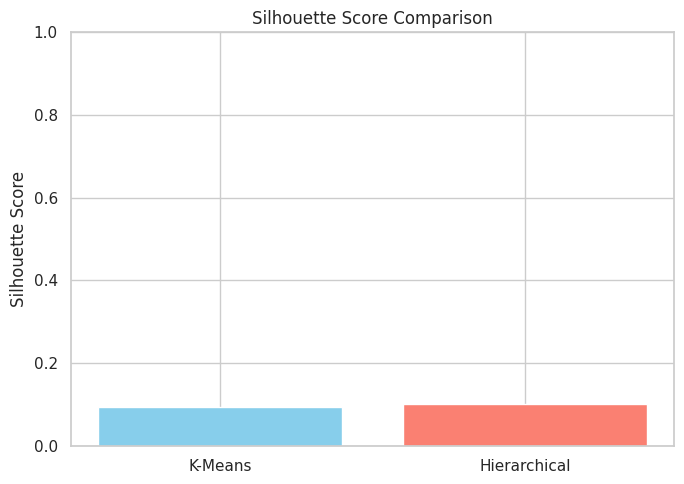

In [43]:
#Bar Chart Comparison
models = ["K-Means", "Hierarchical"]
scores = [kmeans_silhouette, hc_silhouette]
colors = ["skyblue", "salmon"]

plt.figure(figsize=(7,5))
plt.bar(models, scores, color=colors)
plt.title("Silhouette Score Comparison")
plt.ylabel("Silhouette Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

